**1. Geração da Base de Dados Sintética (Mocking) para Jurimetria**

* Como dados de provisões jurídicas e acordos financeiros são estritamente
confidenciais (protegidos por NDAs e sigilo bancário/corporativo), iniciaremos nossa Prova de Conceito (POC) construindo um conjunto de dados sintético.

* O objetivo deste bloco não é apenas gerar números aleatórios, mas sim simular a dinâmica real (a "física") de uma esteira de contencioso. Para isso, utilizamos as bibliotecas numpy e pandas para criar um histórico de 2.500 processos judiciais distribuídos entre 2018 e 2023, incorporando as seguintes regras de negócio e comportamentos estatísticos:

* Categorização de Risco: Os processos são divididos em três naturezas jurídicas com diferentes frequências: Trabalhista (55%, alto volume), Cível (30%, volume médio) e Fraude (15%, baixo volume, mas alto risco).

* Dinâmica Temporal: Utilizamos distribuições estatísticas avançadas para espelhar a realidade dos tribunais. O tempo de tramitação segue uma Distribuição Gamma (simulando processos que costumam se arrastar por anos), enquanto o tempo de liquidação de sentença segue uma Distribuição de Poisson (fase final, geralmente resolvida em poucos meses).

* Composição do Prejuízo: O valor final efetivado (o rombo no caixa) obedece a uma correlação matemática invisível que o nosso modelo tentará descobrir depois. Cada categoria possui um "custo base" e um "custo de manutenção mensal". Por fim, adicionamos um "ruído estatístico" (Distribuição Normal) para representar a incerteza inerente ao humor dos juízes e à complexidade individual de cada causa.

O resultado é um DataFrame cronológico, salvo em um arquivo .csv, que servirá como um laboratório perfeito para validarmos a capacidade preditiva da Regressão Linear Multivariada no controle de passivos jurídicos.

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# Fixando a semente para que os resultados sejam sempre os mesmos na sua apresentação
np.random.seed(42)

# Quantidade de processos para a base de dados
n_processos = 2500

# 1. Gerando IDs únicos
ids_processo = [f"PRC-{200000 + i}" for i in range(n_processos)]

# 2. Definindo as categorias e suas probabilidades na base
categorias = ['Fraude', 'Trabalhista', 'Cível']
probs = [0.15, 0.55, 0.30] # 15% Fraude, 55% Trabalhista, 30% Cível
tipo_acao = np.random.choice(categorias, size=n_processos, p=probs)

# 3. Gerando a Data de Distribuição (entre 2018 e 2023)
data_inicio = datetime(2018, 1, 1)
data_fim = datetime(2023, 12, 31)
dias_totais = (data_fim - data_inicio).days
dias_aleatorios = np.random.randint(0, dias_totais, n_processos)
data_distribuicao = [data_inicio + timedelta(days=int(d)) for d in dias_aleatorios]

# 4. Gerando os Tempos (em meses)
# Tempo de Tramitação (distribuição Gamma para simular processos que demoram anos)
tempo_tramitacao = np.random.gamma(shape=3.0, scale=8.0, size=n_processos).astype(int) + 6

# Tempo de Liquidação (distribuição Poisson para simular pagamentos que saem em poucos meses)
tempo_liquidacao = np.random.poisson(lam=3.0, size=n_processos) + 1

# 5. Calculando o Valor Efetivado (Prejuízo) com base em regras + ruído estatístico
valor_efetivado = []
for i in range(n_processos):
    tipo = tipo_acao[i]
    tramitacao = tempo_tramitacao[i]

    # Definindo um valor base e um custo adicional por mês de atraso conforme a categoria
    if tipo == 'Fraude':
        base = 250000
        mult_mes = 3500  # Juros e multas pesadas
    elif tipo == 'Trabalhista':
        base = 45000
        mult_mes = 800   # Acréscimos trabalhistas padrão
    else: # Cível
        base = 80000
        mult_mes = 1200  # Correção monetária padrão

    # O "ruído" simula fatores que não temos no modelo (complexidade da causa, humor do juiz, etc.)
    ruido = np.random.normal(0, base * 0.25)

    custo_final = base + (tramitacao * mult_mes) + ruido

    # Garantindo que nenhum processo tenha valor negativo ou irrisório
    valor_efetivado.append(max(5000, custo_final))

# 6. Montando o DataFrame
df_jurimetria = pd.DataFrame({
    'ID_Processo': ids_processo,
    'Data_Distribuicao': data_distribuicao,
    'Tipo_Acao': tipo_acao,
    'Tempo_Tramitacao_Meses': tempo_tramitacao,
    'Tempo_Liquidacao_Meses': tempo_liquidacao,
    'Valor_Efetivado_BRL': np.round(valor_efetivado, 2)
})

# Ordenando cronologicamente para facilitar o seu corte de 80/20 depois
df_jurimetria = df_jurimetria.sort_values(by='Data_Distribuicao').reset_index(drop=True)

# Salvando em um arquivo para você usar no seu modelo
df_jurimetria.to_csv('dados_jurimetria_poc.csv', index=False)

print("Base de dados gerada com sucesso!")
print(df_jurimetria.head(10))

Base de dados gerada com sucesso!
  ID_Processo Data_Distribuicao    Tipo_Acao  Tempo_Tramitacao_Meses  \
0  PRC-202470        2018-01-02  Trabalhista                      38   
1  PRC-200815        2018-01-03  Trabalhista                      41   
2  PRC-201383        2018-01-06  Trabalhista                      24   
3  PRC-200305        2018-01-08        Cível                      24   
4  PRC-201769        2018-01-08  Trabalhista                      37   
5  PRC-200325        2018-01-10        Cível                      33   
6  PRC-200432        2018-01-10  Trabalhista                      16   
7  PRC-201057        2018-01-11  Trabalhista                      10   
8  PRC-201646        2018-01-12       Fraude                      24   
9  PRC-200984        2018-01-13        Cível                      16   

   Tempo_Liquidacao_Meses  Valor_Efetivado_BRL  
0                       2             87520.56  
1                       5             70605.11  
2                       4 

**2. Análise Exploratória e Storytelling Visual**

* Antes de aplicarmos a inteligência do algoritmo preditivo multivariado,
precisamos provar para os tomadores de decisão que existem padrões matemáticos ocultos no aparente "caos" dos passivos jurídicos. Este bloco utiliza as bibliotecas matplotlib e seaborn para traduzir a base de dados em um Dashboard executivo focado em três visões estratégicas:

  A. Distribuição Global (Histograma): Avalia a saúde geral do nosso contencioso. Ele revela onde a grande massa de custos se concentra e evidencia a "cauda longa" de processos extremos que distorcem o nosso caixa.

  B. Risco por Categoria (Boxplot): Permite comparar lado a lado o impacto financeiro das ações Trabalhistas, Cíveis e de Fraude. É a ferramenta ideal para identificar rapidamente a variância dos custos e os piores outliers (processos com rombos fora da curva).

  C. Tendência Temporal (Dispersão Múltipla): É a validação visual da nossa tese principal. Ao cruzar o tempo de tramitação com o prejuízo final, e traçar retas de regressão simples isoladas por cor, provamos inequivocamente que "tempo é dinheiro". Fica claro que a taxa de crescimento do custo (a inclinação da reta) depende estritamente da natureza da ação.

Este painel comprova visualmente que os custos processuais seguem regras lógicas, justificando o investimento no modelo de Machine Learning da próxima etapa.

/tmp/ipykernel_1919/2689933007.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Tipo_Acao', y='Valor_Efetivado_BRL', palette='Set2', ax=axes[1])


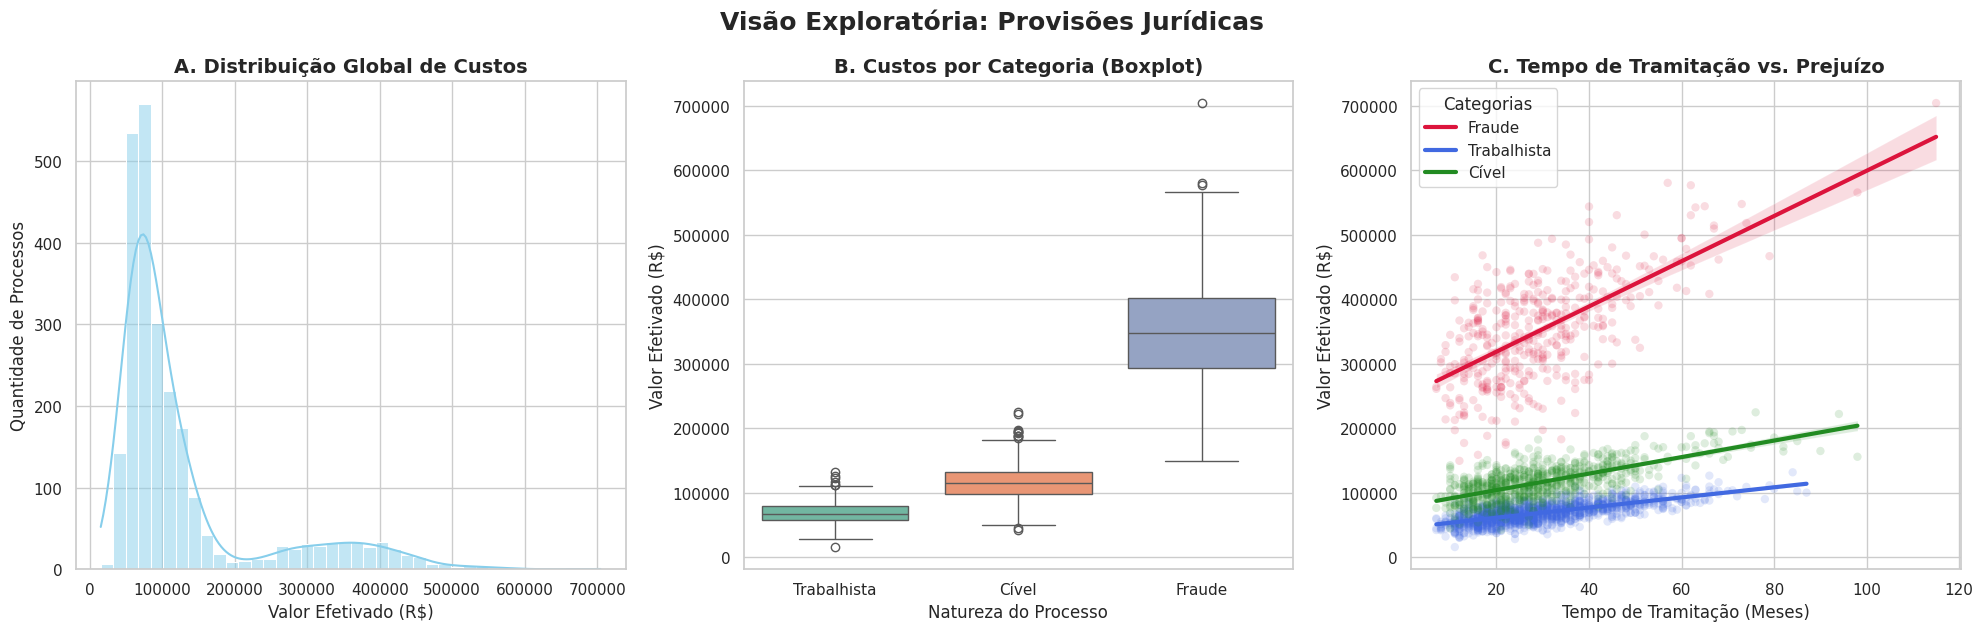

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================================
# 1. PREPARAÇÃO DA BASE E ESTILO
# =====================================================================
# Carregando a base de dados sintética que geramos nos passos anteriores
df = pd.read_csv('dados_jurimetria_poc.csv')

# Configurando o estilo visual dos gráficos (fundo limpo com grade leve)
sns.set_theme(style="whitegrid")

# =====================================================================
# 2. CRIAÇÃO DO DASHBOARD (1 Linha, 3 Colunas)
# =====================================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- GRÁFICO A: Histograma de Custos (Distribuição) ---
sns.histplot(data=df, x='Valor_Efetivado_BRL', bins=40, kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('A. Distribuição Global de Custos', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Valor Efetivado (R$)')
axes[0].set_ylabel('Quantidade de Processos')

# --- GRÁFICO B: Boxplot por Categoria ---
sns.boxplot(data=df, x='Tipo_Acao', y='Valor_Efetivado_BRL', palette='Set2', ax=axes[1])
axes[1].set_title('B. Custos por Categoria (Boxplot)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Natureza do Processo')
axes[1].set_ylabel('Valor Efetivado (R$)')

# --- GRÁFICO C: Dispersão Múltipla (Tempo vs. Custo por Categoria) ---
# Definindo cores estratégicas para criar alto contraste
paleta_cores = {'Fraude': 'crimson', 'Trabalhista': 'royalblue', 'Cível': 'forestgreen'}

# Iteramos sobre cada categoria para plotar sua própria nuvem de pontos e reta
for categoria, cor in paleta_cores.items():
    # Filtramos apenas os dados da categoria atual do loop
    df_subset = df[df['Tipo_Acao'] == categoria]

    # Plotamos a regressão isolada dessa categoria no axes[2]
    sns.regplot(
        data=df_subset,
        x='Tempo_Tramitacao_Meses',
        y='Valor_Efetivado_BRL',
        ax=axes[2],
        color=cor,
        # scatter_kws controla os pontos experimentais (alpha=0.2 deixa bem transparente)
        scatter_kws={'alpha': 0.15, 'edgecolor': 'none'},
        # line_kws controla a reta de ajuste (forte e destacada)
        line_kws={'linewidth': 3, 'label': categoria}
    )

axes[2].set_title('C. Tempo de Tramitação vs. Prejuízo', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Tempo de Tramitação (Meses)')
axes[2].set_ylabel('Valor Efetivado (R$)')
# Adicionando a legenda para identificar qual reta é de qual categoria
axes[2].legend(title="Categorias", fontsize=11, title_fontsize=12)

# =====================================================================
# 3. FINALIZAÇÃO E EXPORTAÇÃO
# =====================================================================
# Ajustando os espaços para não sobrepor os títulos e rótulos
plt.tight_layout()

# Adicionando um super título para coroar a apresentação
fig.suptitle('Visão Exploratória: Provisões Jurídicas', y=1.05, fontsize=18, fontweight='bold')

# Salvando a figura em alta resolução para os slides
plt.savefig('dashboard_jurimetria_completo.png', dpi=300, bbox_inches='tight')

# Exibindo o resultado final na tela
plt.show()

**3a. Modelagem Preditiva e Forecasting (Regressão Linear Multivariada)**

Nesta etapa final, saímos da análise descritiva (o que aconteceu) e entramos na análise preditiva (o que vai acontecer). O objetivo é construir um algoritmo capaz de prever o custo de um processo judicial antes mesmo dele ser finalizado.Para isso, utilizamos a mesma matemática de otimização de portfólios e taxas de juros (Mínimos Quadrados), mas com uma Engenharia de Variáveis (Feature Engineering) voltada para a nossa regra de negócio:

* Fatiamento do Tempo: O modelo não olha apenas para o tempo total. Ele quebra o processo em 1ª Instância, Recursos e Liquidação.

* Variáveis Dummy: As naturezas jurídicas (Fraude, Cível) são transformadas em sinais binários (0 ou 1) para que a álgebra linear consiga calcular o peso exato de cada categoria.

**3b. A Divisão do Tempo e o Forecasting:**

Para provar que o modelo funciona no mundo real, dividimos a nossa base de dados cronologicamente:

* Treino (Passado - 80%): O algoritmo analisa os processos antigos para calcular as matrizes de correlação e encontrar os pesos ideais ($w$) de cada fase e categoria.

* Teste (Futuro - 20%): O algoritmo é forçado a prever os custos dos processos mais recentes, dados que ele nunca viu antes.

**3c. Lendo os Resultados e o Gráfico:**

O modelo imprimirá os pesos calculados: o "Bias" representa o custo base de entrada, enquanto os demais valores mostram o custo mensal em cada fase ou o agravante por categoria. O gráfico gerado ilustrará essa precisão, mostrando a linha de previsão do modelo (laranja) perseguindo o custo real que foi efetivado (linha preta) na área de Teste.

**3d.⚠️ Alerta Estratégico: O Perigo do Overfitting:**

 É tentador adicionar dezenas de variáveis ao modelo (ex: nome do juiz, vara, estado, escritório de advocacia) na tentativa de zerar o erro da previsão. Cuidado! Modelos supercomplexos sofrem de Overfitting (sobreajuste). Eles "decoram" perfeitamente os dados do passado (Treino), mas perdem a capacidade de generalização, falhando miseravelmente ao tentar prever processos novos (Teste). A regressão linear apresentada aqui foca em poucas variáveis macro, garantindo robustez a longo prazo.

--- PESOS CALCULADOS PELO MODELO (O que a IA aprendeu) ---
Bias (Custo Base Trabalhista) : R$ 23879.66
Custo por mês (1ª Instância)  : R$ 1109.82
Custo por mês (Recursos)      : R$ 1672.07
Custo por mês (Liquidação)    : R$ 365.67
Acréscimo fixo se for Fraude  : R$ 283963.13
Acréscimo fixo se for Cível   : R$ 47825.66

Erro Médio da Previsão no Teste: R$ 18755.43



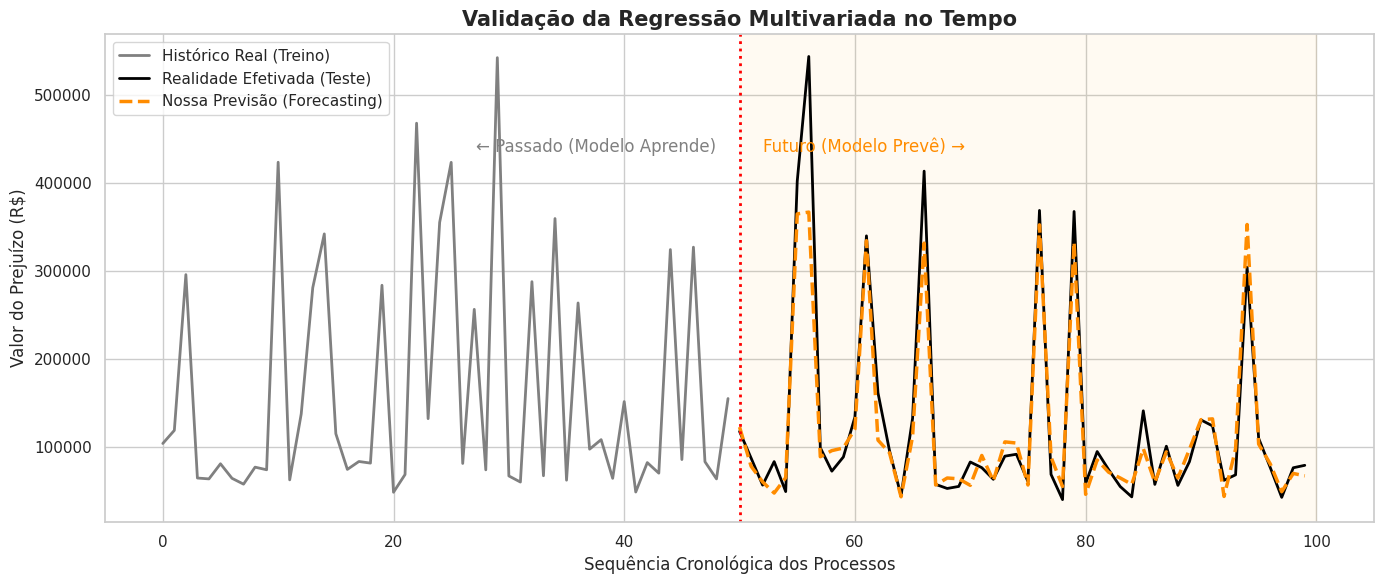

In [7]:
# =====================================================================
# 3. ENGENHARIA DE VARIÁVEIS (Feature Engineering)
# Transformando o tempo total nas "fases" da esteira processual
# =====================================================================
# REGRA DE NEGÓCIO APLICADA:
# Na realidade, processos rápidos (ex: < 12 meses) geralmente terminam em
# acordo na 1ª Instância e nunca sobem para os Tribunais (Recursos).
# Para processos longos (> 12 meses), assumimos que 40% do tempo foi na
# 1ª Instância e o restante foi gasto na fase de Recursos.

df['Tempo_1a_Instancia'] = np.where(
    df['Tempo_Tramitacao_Meses'] <= 12,
    df['Tempo_Tramitacao_Meses'],                       # Se <= 12, 100% do tempo foi aqui
    np.floor(df['Tempo_Tramitacao_Meses'] * 0.4)        # Se > 12, apenas 40% do tempo
)

df['Tempo_Recursos'] = np.where(
    df['Tempo_Tramitacao_Meses'] <= 12,
    0,                                                  # Não houve recurso (acordo)
    df['Tempo_Tramitacao_Meses'] - df['Tempo_1a_Instancia'] # Restante do tempo
)

# Criando as variáveis Dummy para as categorias (0 e 1)
# O algoritmo usará a categoria Trabalhista como "Base" (quando Fraude=0 e Cível=0)
df['Is_Fraude'] = np.where(df['Tipo_Acao'] == 'Fraude', 1, 0)
df['Is_Civel'] = np.where(df['Tipo_Acao'] == 'Cível', 1, 0)


# =====================================================================
# 4. PREPARAÇÃO DAS MATRIZES E DIVISÃO NO TEMPO (80/20)
# =====================================================================
N_total = len(df)
N_treino = int(N_total * 0.8) # O passado (80% mais antigos)
N_teste = N_total - N_treino  # O futuro (20% mais recentes)

# Construindo a Matriz de Características (X)
bias = np.ones(N_total)
x1 = df['Tempo_1a_Instancia'].values
x2 = df['Tempo_Recursos'].values
x3 = df['Tempo_Liquidacao_Meses'].values
x4 = df['Is_Fraude'].values
x5 = df['Is_Civel'].values

X = np.vstack((bias, x1, x2, x3, x4, x5)).T
d = df['Valor_Efetivado_BRL'].values

# Separando Treino (Histórico) e Teste (Forecasting)
X_treino, X_teste = X[:N_treino], X[N_treino:]
d_treino, d_teste = d[:N_treino], d[N_treino:]


# =====================================================================
# 5. OTIMIZAÇÃO: CRITÉRIO DOS MÍNIMOS QUADRADOS (Least Squares)
# =====================================================================
# Calculando a matriz R e o vetor p para resolver o sistema linear
R = X_treino.T @ X_treino
p = X_treino.T @ d_treino

# A mágica linear matemática (encontrando os pesos que minimizam o erro)
w = np.linalg.solve(R, p)

print("--- PESOS CALCULADOS PELO MODELO (O que a IA aprendeu) ---")
print(f"Bias (Custo Base Trabalhista) : R$ {w[0]:.2f}")
print(f"Custo por mês (1ª Instância)  : R$ {w[1]:.2f}")
print(f"Custo por mês (Recursos)      : R$ {w[2]:.2f}")
print(f"Custo por mês (Liquidação)    : R$ {w[3]:.2f}")
print(f"Acréscimo fixo se for Fraude  : R$ {w[4]:.2f}")
print(f"Acréscimo fixo se for Cível   : R$ {w[5]:.2f}\n")


# =====================================================================
# 6. FORECASTING: AVALIAÇÃO VISUAL DO MODELO
# =====================================================================
# Gerando as previsões apenas para os dados que o modelo NUNCA viu
y_estimado = X_teste @ w

# Métrica de Erro
erro_absoluto = np.abs(d_teste - y_estimado)
print(f"Erro Médio da Previsão no Teste: R$ {erro_absoluto.mean():.2f}\n")

# --- Construção do Gráfico Didático ---
plt.figure(figsize=(14, 6))

# Para o gráfico não virar um borrão ilegível, vamos pegar uma "janela" contínua:
# Os últimos 50 processos do Treino e os primeiros 50 processos do Teste
janela_treino = 50
janela_teste = 50

# Eixos X (Índices temporais)
idx_treino = np.arange(janela_treino)
idx_teste = np.arange(janela_treino, janela_treino + janela_teste)

# Plotando os dados reais do passado (Treino)
plt.plot(idx_treino, d_treino[-janela_treino:], color='gray', linewidth=2, label='Histórico Real (Treino)')

# Plotando os dados reais do futuro (Teste)
plt.plot(idx_teste, d_teste[:janela_teste], color='black', linewidth=2, label='Realidade Efetivada (Teste)')

# Plotando a nossa previsão tentando acompanhar a realidade
plt.plot(idx_teste, y_estimado[:janela_teste], color='darkorange', linestyle='--', linewidth=2.5, label='Nossa Previsão (Forecasting)')

# --- Elementos de Distinção (A Fronteira do Tempo) ---
# Linha vertical vermelha representando o limite de aprendizado
plt.axvline(x=janela_treino, color='red', linestyle=':', linewidth=2)
plt.text(janela_treino - 2, max(d_teste[:janela_teste])*0.8, '← Passado (Modelo Aprende)', color='gray', ha='right')
plt.text(janela_treino + 2, max(d_teste[:janela_teste])*0.8, 'Futuro (Modelo Prevê) →', color='darkorange', ha='left')

# Sombreado sutil na área de teste
plt.axvspan(janela_treino, janela_treino + janela_teste, color='orange', alpha=0.05)

# Perfumaria do Gráfico
plt.title('Validação da Regressão Multivariada no Tempo', fontsize=15, fontweight='bold')
plt.xlabel('Sequência Cronológica dos Processos')
plt.ylabel('Valor do Prejuízo (R$)')
plt.legend(loc='upper left')
plt.tight_layout()

plt.savefig('forecasting_temporal_jurimetria.png', dpi=300)
plt.show()